# Data prep illustration


In [1]:
import os

import astropy.io.fits as pyfits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.interpolate import interp1d

from sdss.metadata import MetaData
from anomaly.utils import specobjid_to_idx

meta = MetaData()

# Custom functions

## Data from fits

In [2]:
def get_data_from_fits_file(file_path):
    """
    Get flux, sky, wave and ivar from a SDSS fits file.
    The fits file come from spec lite version of SDSS
    data reduction pipeline.
    """

    with pyfits.open(file_path, memmap=False) as hdul:
        # Get the data from HDU 1 (COADD)
        data = hdul[1].data
        specobjid = int(hdul[2].data["specobjid"].item())

    wavelength = 10**data['loglam']
    flux = data['flux']
    sky = data['SKY']
    ivar = data['ivar']
    
    return flux, sky, wavelength, ivar, specobjid

## OI interpolation

In [3]:
def OI_5577_interpolation(wave: np.array, spectrum: np.array) -> np.array:
    """
    Interpolate region of airglow radiation from the
    [OI]5577 region with the average flux of neighboring
    segments to that region

    INPUTS
    wave: wavelengths of the raw spectrum in observers
        frame
    spectrum: flux of spectrum in observers frame

    OUTPUT
    spectrum: flux with interpolation of the [OI]5577
        region caused by atmospheric airglow
    """

    OI_mask = np.logical_and(wave > 5565, wave < 5590)
    n_mask = OI_mask.sum()

    try:

        left_idx = np.argwhere(wave == wave[OI_mask][0])[0, 0]
        right_idx = np.argwhere(wave == wave[OI_mask][-1])[0, 0]

    except IndexError:

        return spectrum

    left_flux = spectrum[left_idx - n_mask : left_idx]
    right_flux = spectrum[right_idx : right_idx + n_mask]

    average_flux = (left_flux + right_flux) / 2.0

    spectrum[OI_mask] = average_flux

    return spectrum

### OI indicator

In [4]:
def add_oi_indicator(
    ax, wave, spec,
    indicator_starts,
    indicator_height,
    delta=1,
    indicator_color='blue',
    indicator_label_color='black',
    lw=1,
    fontsize=6,
):
    line_name = 'OI'
    line_wave = 557.7

    line_flux = np.max(
        spec[(wave > line_wave - delta) & (wave < line_wave + delta)]
    )

    # Plot vertical line indicator
    y_start_indicator = line_flux + indicator_starts
    y_end_indicator = y_start_indicator + indicator_height

    ax.plot(
        [line_wave, line_wave], 
        [y_start_indicator, y_end_indicator], 
        color=indicator_color, lw=lw
    )

    y_text_start = y_end_indicator + indicator_height/2

    ax.text(
        line_wave, 
        y_text_start, 
        line_name,
        ha='center', va='bottom', 
        fontsize=fontsize, rotation=90, 
        color=indicator_label_color
    )

    return ax

## Pixel noise masking

In [12]:
def remove_large_uncertainties(
    wave, flux, ivar
) -> np.array:
    """
    Set to NaN fluxes with large variance in their measurements

    INPUT
    flux: raw spectrum
    ivar: inverse of variance for fluxe measurements of spectrum

    OUTPUTS

    flux, variance: masked flux with large noise in its measurements
        and variance of flux measurements
    """

    flux = OI_5577_interpolation(wave, flux)
    n_nan_prior_masking = np.isnan(flux).sum()
    
    # Get variance of each flux
    ivar[ivar == 0] = np.nan
    variance = 1 / ivar
    variance[np.isnan(ivar)] = np.inf
    variance = np.nan_to_num(variance)

    # mask of: variance > flux [higly uncertain values]
    flux_no_nans = np.nan_to_num(flux)
    large_variance_mask = np.sqrt(variance) > flux_no_nans

    flux[large_variance_mask] = np.nan
    n_nan_after_masking = np.isnan(flux).sum()

    print(f"N of NaNs before masking: {n_nan_prior_masking}")
    print(f"N of NaNs after masking: {n_nan_after_masking}")

    return flux, variance

## Dered spectrum

In [13]:
def dust_model() -> object:
    """Extinction function to dered spectra"""
    # dust model for dereden_spectrum
    wave = np.array([2600, 2700, 4110, 4670, 5470, 6000, 12200, 26500])

    extinction = np.array(
        [6.591, 6.265, 4.315, 3.806, 3.055, 2.688, 0.829, 0.265]
    )

    extinction = interp1d(wave, extinction, kind="cubic")

    return extinction

def dered_spectrum(
    flux: np.array, wave: np.array, ebv: float
) -> np.array:

    """
    Apply extinction function to spectrum for deredening.

    INPUTS
    flux: spectrum fluxes in observer frame
    wave: wavelengths of spectrum in observer frame
    ebv: E(B-v) from from Schlegel, Finkbeiner & Davis (1998)

    OUTPUT
    dered_flux: fluxes corrected by extinction
    """
    extinction_fn = dust_model()
    # extinction array for this spectrum
    extinction = extinction_fn(wave)
    extinction *= ebv

    dereded_flux = flux * 10 ** (extinction / 2.5)

    return dereded_flux

## OI + Noise + dered

In [15]:
def OI_noise_dered(wave, flux, ivar, ebv):

    flux, variance = remove_large_uncertainties(
        flux, ivar
    )

    flux = dered_spectrum(flux, wave, ebv=ebv)

    return flux, wave


## Common grid interpolation

In [16]:
lower, upper = 3500, 7500
number_waves = 4000
wave_grid = np.linspace(lower, upper, number_waves)
print(wave_grid.min(), wave_grid.max())

def common_grid_interp(wave_grid, wave, flux, z):

    rest_wave = wave / (1 + z)

    interp_flux = np.interp(
        wave_grid, rest_wave,
        flux,
        left=np.nan, right=np.nan
    )

    return interp_flux

3500.0 7500.0


# Directories

In [17]:
thesis_dir = "/home/elom/gdrive/career/portfolio/phd/thesis_phd"
ch_3_dir = f"{thesis_dir}/chapters/03_figures"

data_dir = "/home/elom/phd/code_phd/spectra"
fits_files_dir = f"{data_dir}/fits_files_illustrations"
bin_id = "bin_03"

# Data ingestion

In [18]:
wave = np.load(f"{data_dir}/wave_spectra_imputed.npy")

spectra = np.load(
    f"{data_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

idx_id_bin_03 = np.load(
    f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)

# Metadata
drop_meta_data_df = pd.read_csv(
    f"{data_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

bin_03_df = drop_meta_data_df.loc[idx_id_bin_03[:, 1]].copy()

# [OI] 557.7 nm interpolation

## Data

In [19]:
file_location = f'{fits_files_dir}/spec-2636-54082-0164.fits'
# file_location = f'{fits_files_dir}/spec-1587-52964-0435.fits'
# -------------------------------------------------
(
    raw_flux, sky,
    raw_wave, ivar, specobjid
) = get_data_from_fits_file(file_location)
# -------------------------------------------------
flux_OI_interp = OI_5577_interpolation(
    raw_wave.copy(), raw_flux.copy()
)
# -------------------------------------------------
# mask for visualization
# OI_mask = (raw_wave > 540) & (raw_wave < 580)
OI_mask = raw_wave < 7500

raw_wave = raw_wave[OI_mask]
raw_flux = raw_flux[OI_mask]
flux_OI_interp = flux_OI_interp[OI_mask]
sky = sky[OI_mask]
ivar = ivar[OI_mask]

# -------------------------------------------------
median_flux_sky = np.nanmedian(raw_flux + sky)
median_sky = np.nanmedian(sky)
median_flux = np.nanmedian(raw_flux)
median_flux_OI_interp = np.nanmedian(flux_OI_interp)

print(f"Median raw flux + sky: {median_flux_sky:.2f}")
print(f"Median sky: {median_sky:.2f}")
print(f"Median raw flux: {median_flux:.2f}")
print(f"Median raw flux (OI interpolated): {median_flux_OI_interp:.2f}")
# -------------------------------------------------

Median raw flux + sky: 50.33
Median sky: 6.85
Median raw flux: 43.43
Median raw flux (OI interpolated): 43.43


## Figure

'http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2967917302898518016&apid='

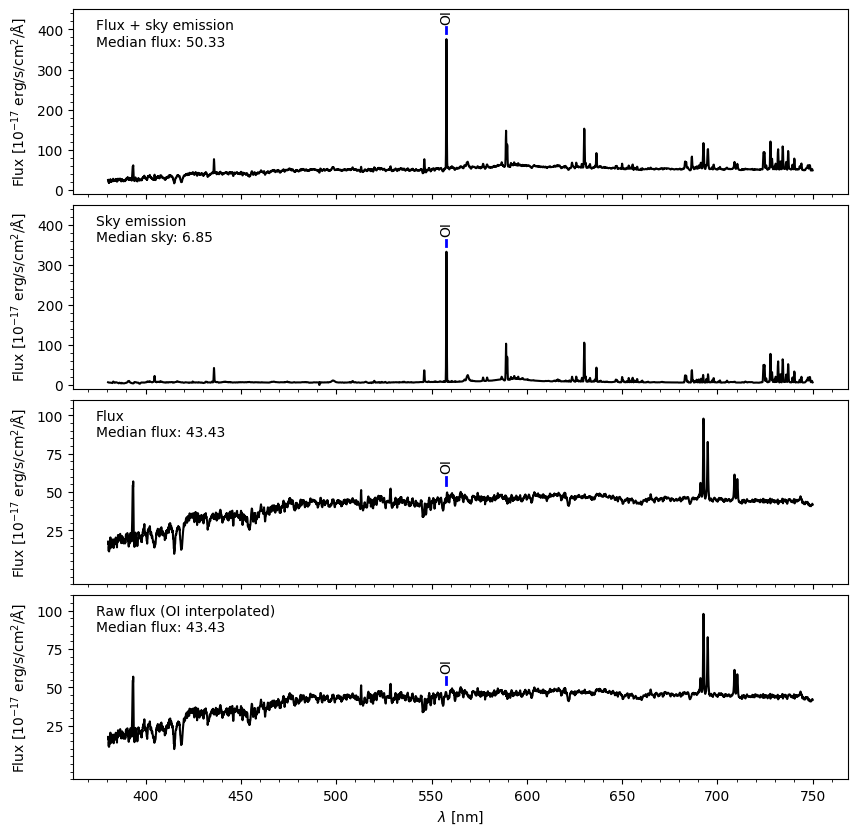

In [20]:
fig, axs = plt.subplots(
    4, 1,
    figsize=(10, 10),
    sharex=True,
)
# -------------------------------------------------
y_label = r'Flux [$10^{-17}$ erg/s/cm$^2$/Å]'
raw_wave *= 0.1
# -------------------------------------------------
# raw_flux + sky
axs[0].plot(raw_wave, raw_flux + sky, color='black')

axs[0].text(
    0.03, 0.95,
    f'Flux + sky emission\nMedian flux: {median_flux_sky:.2f}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[0].set_ylim(-10, 450) 
ticks = [0, 100, 200, 300, 400]
axs[0].set_yticks(ticks)

add_oi_indicator(
    axs[0], raw_wave,
    raw_flux + sky,
    indicator_starts=15,
    indicator_height=15,
    delta=1,
    lw=2,
    fontsize=10,
)
axs[0].set_ylabel(y_label)
# -------------------------------------------------
# Sky
axs[1].plot(raw_wave, sky, color='black')

axs[1].text(
    0.03, 0.95,
    f'Sky emission\nMedian sky: {median_sky:.2f}', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[1].set_ylim(-10, 450) 
ticks = [0, 100, 200, 300, 400]
axs[1].set_yticks(ticks)

add_oi_indicator(
    axs[1], raw_wave,
    sky,
    indicator_starts=15,
    indicator_height=15,
    delta=1,
    lw=2,
    fontsize=10,
)
# -------------------------------------------------
# Flux
axs[2].plot(raw_wave, raw_flux, color='black')

axs[2].text(
    0.03, 0.95,
    f'Flux\nMedian flux: {median_flux:.2f}', 
    transform=axs[2].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[2].set_ylim(-10, 110) 
ticks = [25, 50, 75, 100]
axs[2].set_yticks(ticks)

add_oi_indicator(
    axs[2], raw_wave, raw_flux,
    indicator_starts=5,
    indicator_height=5,
    delta=1,
    lw=2,
    fontsize=10,
)
# -------------------------------------------------
# Flux OI interpolated
axs[3].plot(raw_wave, raw_flux_OI_interpolated, color='black')

axs[3].text(
    0.03, 0.95,
    f'Raw flux (OI interpolated)\nMedian flux: {median_flux_OI_interpolated:.2f}', 
    transform=axs[3].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[3].set_ylim(-10, 110) 
ticks = [25, 50, 75, 100]
axs[3].set_yticks(ticks)

add_oi_indicator(
    axs[3], raw_wave, raw_flux_OI_interpolated,
    indicator_starts=5,
    indicator_height=5,
    delta=1,
    lw=2,
    fontsize=10,
)
# -------------------------------------------------
axs[-1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten():
    ax.minorticks_on()
    ax.set_ylabel(y_label)

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    # wspace=0.1
)
fig.savefig(
    f"{ch_3_dir}/OI_line_removal.pdf",
    bbox_inches='tight'
)
meta.get_sky_server_url(specobjid)

# Pixel-level noise masking

## Data

In [ ]:
# file_location = f'{fits_files_dir}/spec-1036-52582-0545.fits' # 220 Nans
# file_location = f'{fits_files_dir}/spec-1171-52753-0494.fits' # 71 Nans

# -------------------------------------------------
(
    raw_flux, sky,
    raw_wave, ivar, specobjid
) = get_data_from_fits_file(file_location)
# -------------------------------------------------
flux_noise_masked, variance = remove_large_uncertainties(
    raw_wave, raw_flux, ivar
)

N of NaNs before masking: 0
N of NaNs after masking: 0


## Figure

'http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=1318564626786445312&apid='

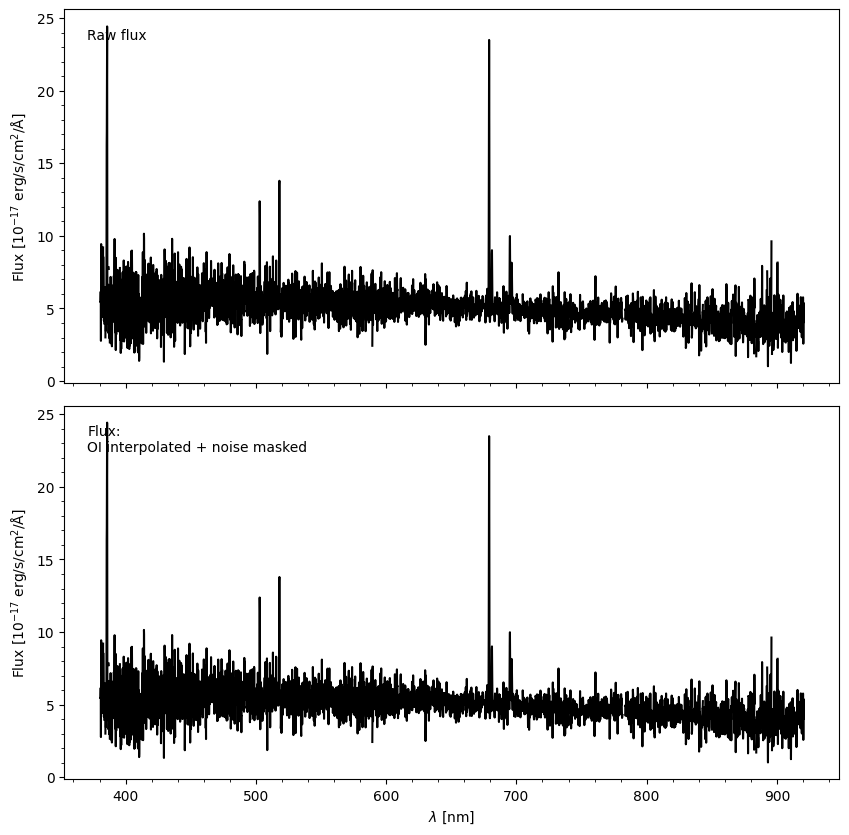

In [32]:
# looks like here it is best to show the places masked
# also try to find objects with a lot of masking

fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 10),
    sharex=True,
)
# -------------------------------------------------
y_label = r'Flux [$10^{-17}$ erg/s/cm$^2$/Å]'
# convert to nm
raw_wave_nm = raw_wave * 0.1
# -------------------------------------------------
# OI_mask = (raw_wave > 540) & (raw_wave < 580)
# OI_mask = raw_wave < 750

# raw_wave = raw_wave[OI_mask]
# raw_flux = raw_flux[OI_mask]
# sky = sky[OI_mask]
# ivar = ivar[OI_mask]


# Flux OI interpolated
axs[0].plot(raw_wave_nm, raw_flux, color='black')
    
axs[0].text(
    0.03, 0.95,
    f'Raw flux', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

# axs[0].set_ylim(-10, 110) 
# ticks = [25, 50, 75, 100]
# axs[0].set_yticks(ticks)

axs[0].set_ylabel(y_label)

# -------------------------------------------------
# Flux OI noise masked
axs[1].plot(raw_wave_nm, flux_noise_masked, color='black')
    
axs[1].text(
    0.03, 0.95,
    f'Flux:\nOI interpolated + noise masked', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

# axs[1].set_ylim(-10, 110) 
# ticks = [25, 50, 75, 100]
# axs[1].set_yticks(ticks)


axs[1].set_ylabel(y_label)
# -------------------------------------------------
axs[-1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    # wspace=0.1
)
fig.savefig(
    f"{ch_3_dir}/noise_masking.pdf",
    bbox_inches='tight'
)
meta.get_sky_server_url(specobjid)

# Galactic extinction correction

In [31]:
# Find large 'ebv'
sf_mask = drop_meta_data_df['subClass'] == 'STARFORMING'
cols = [
    'mjd', 'plate', 'fiberid', 'run2d', 'ra', 'dec',
    'snMedian', 'ebv', 'z', 'subClass'
]
ebv_df = drop_meta_data_df.loc[sf_mask, cols].sort_values(by='ebv', ascending=False).copy()
ebv_df.head()

,mjd,plate,fiberid,run2d,ra,dec,snMedian,ebv,z,subClass
specobjid,,,,,,,,,,
1414177610681837568,52902,1256,172,26,68.764938,25.183876,15.888740,1.131693,0.012981,STARFORMING
1413064905921161216,52962,1255,220,26,66.772216,24.200984,8.212399,0.732274,0.062577,STARFORMING
1408595940943620096,52964,1251,346,26,63.877387,29.390476,15.208120,0.724849,0.050034,STARFORMING
1415285919107278848,52944,1257,108,26,71.478404,24.145436,16.203650,0.581712,0.077093,STARFORMING
1408652565792450560,52964,1251,552,26,65.583319,29.320077,24.924560,0.483340,0.025235,STARFORMING


In [30]:
ebv_df.ebv.describe()

count    223367.000000
mean          0.028643
std           0.019774
min           0.002608
25%           0.016091
50%           0.023762
75%           0.035221
max           1.131693
Name: ebv, dtype: float64

In [32]:
end_idx = 0
for specobjid, row in ebv_df.iterrows():
    print(
        # f"SpecObjID: {specobjid},"
        f"S/N: {row['snMedian']},"
        f"z: {row['z']},"
        f"subClass: {row['subClass']},"
        f"ebv: {row['ebv']}"        
    )
    plate = row['plate']
    sas_path = meta.get_file_location_sas(row)
    sdss_sas_link = (
        f"https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/{plate}/"
    )
    print(sdss_sas_link)
    print(f"SAS path: {sas_path[-1]}\n\n")
    end_idx += 1
    if end_idx == 100:
        break

S/N: 15.88874,z: 0.01298113,subClass: STARFORMING,ebv: 1.131692638600582
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1256/
SAS path: spec-1256-52902-0172


S/N: 8.212399,z: 0.06257688,subClass: STARFORMING,ebv: 0.7322735919716721
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1255/
SAS path: spec-1255-52962-0220


S/N: 15.20812,z: 0.05003415,subClass: STARFORMING,ebv: 0.7248492017240291
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1251/
SAS path: spec-1251-52964-0346


S/N: 16.20365,z: 0.07709317,subClass: STARFORMING,ebv: 0.5817119018103802
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1257/
SAS path: spec-1257-52944-0108


S/N: 24.92456,z: 0.02523474,subClass: STARFORMING,ebv: 0.483339817045612
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/1251/
SAS path: spec-1251-52964-0552


S/N: 17.06718,z: 0.05482152,subClass: STARFORMING,ebv: 0.4436302120535938
https://data.sdss.org/sas/dr16/sd

E(B-V): 0.4226


'http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=1411935982525114368&apid='

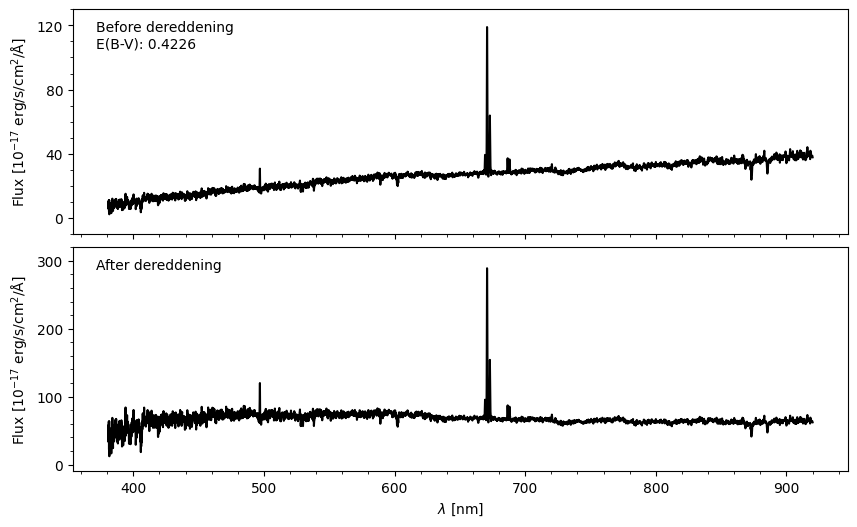

In [77]:
file_location = f'{fits_files_dir}/spec-1254-52972-0209.fits' # love it
# file_location = f'{fits_files_dir}/spec-1251-52964-0552.fits' # love it
# file_location = f'{fits_files_dir}/spec-1254-52972-0339.fits' # love it
# file_location = f'{fits_files_dir}/spec-0743-52262-0240.fits' # passive
# file_location = f'{fits_files_dir}/'
# file_location = f'{fits_files_dir}/'

# -------------------------------------------------
(
    raw_flux, sky,
    raw_wave, ivar, specobjid
) = get_data_from_fits_file(file_location)


raw_flux_OI_interpolated = OI_5577_interpolation(
    raw_wave.copy(), raw_flux.copy()
)

flux_noise_masking, variance = remove_large_uncertainties(
    raw_flux_OI_interpolated, ivar
)

ebv = drop_meta_data_df.loc[specobjid, 'ebv']
print(f"E(B-V): {ebv:.4f}")

dered_flux = dered_spectrum(raw_flux_OI_interpolated, raw_wave, ebv=ebv)

# -------------------------------------------------
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
)
# -------------------------------------------------
y_label = r'Flux [$10^{-17}$ erg/s/cm$^2$/Å]'
# -------------------------------------------------
# convert to nanometers
raw_wave *= 0.1
# Flux OI interpolated
axs[0].plot(raw_wave, flux_noise_masking, color='black')
    
axs[0].text(
    0.03, 0.95,
    f'Before dereddening\nE(B-V): {ebv:.4f}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[0].set_ylim(-10, 130) 
ticks = [0, 40, 80, 120]
axs[0].set_yticks(ticks)

axs[0].set_ylabel(y_label)

# -------------------------------------------------
# Flux OI noise masked
axs[1].plot(raw_wave, dered_flux, color='black')
    
axs[1].text(
    0.03, 0.95,
    f'After dereddening', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)

axs[1].set_ylim(-10, 320) 
ticks = [0, 100, 200, 300]
axs[1].set_yticks(ticks)


axs[1].set_ylabel(y_label)
# -------------------------------------------------
axs[-1].set_xlabel(r"$\lambda$ [nm]")
# 
for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
plt.subplots_adjust(
    hspace=0.06,
    # wspace=0.1
)
fig.savefig(
    f"{ch_3_dir}/gal_ext_corr_{specobjid}.pdf",
    bbox_inches='tight'
)
meta.get_sky_server_url(specobjid)

# Rest frame

In [84]:
ebv_df.sort_values(by='z', ascending=False).head(50)

,mjd,plate,fiberid,run2d,ra,dec,snMedian,ebv,z,subClass
specobjid,,,,,,,,,,
2666233297033521152,53758,2368,372,26,141.609730,17.821009,7.512844,0.027724,0.298085,STARFORMING
1837576725249157120,52996,1632,393,26,54.563758,0.129323,8.941917,0.074193,0.297629,STARFORMING
1777947743776434176,53473,1579,552,26,239.556820,30.822075,13.235080,0.028590,0.294767,STARFORMING
2496214440244963328,53794,2217,343,26,170.226240,29.787874,10.010140,0.014421,0.294071,STARFORMING
923266002060339200,52438,820,102,26,254.994980,35.935977,9.104266,0.014792,0.293984,STARFORMING
1837582497685202944,52996,1632,414,26,55.112133,1.149572,7.486722,0.099521,0.293949,STARFORMING
1836465968340035584,54469,1631,448,26,55.448064,-5.184587,10.021070,0.041753,0.293565,STARFORMING
1242031197803014144,52873,1103,595,26,336.265370,0.337456,7.966941,0.067252,0.293089,STARFORMING
1031495603500115968,52378,916,623,26,213.921660,-1.954484,9.071104,0.055134,0.292947,STARFORMING


In [85]:
# get sas link
specobjid = 622684254672807936
row = ebv_df.loc[specobjid]
print(
    # f"SpecObjID: {specobjid},"
    f"S/N: {row['snMedian']},"
    f"z: {row['z']},"
    f"subClass: {row['subClass']},"
    f"ebv: {row['ebv']}"        
)
plate = row['plate']
sas_path = meta.get_file_location_sas(row)
sdss_sas_link = (
    f"https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/{plate}/"
)
print(sdss_sas_link)
print(f"SAS path: {sas_path[-1]}\n\n")

S/N: 15.54379,z: 0.2887765,subClass: STARFORMING,ebv: 0.0141546265985616
https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/553/
SAS path: spec-0553-51999-0224




## Data

In [98]:
# Spec 1
spec_1_location = f'{fits_files_dir}/spec-1254-52972-0209.fits'
(
    raw_flux_1, sky_1,
    raw_wave_1, ivar_1, specobjid_1
) = get_data_from_fits_file(spec_1_location)


raw_flux_OI_interpolated_1 = OI_5577_interpolation(
    raw_wave_1.copy(), raw_flux_1.copy()
)

flux_noise_masking_1, variance_1 = remove_large_uncertainties(
    raw_flux_OI_interpolated_1, ivar_1
)

ebv_1 = drop_meta_data_df.loc[specobjid_1, 'ebv']

dered_flux_1 = dered_spectrum(raw_flux_OI_interpolated_1, raw_wave_1, ebv=ebv_1)
# convert to nanometers
raw_wave_1 *= 0.1
z_1 = drop_meta_data_df.loc[specobjid_1, 'z']
rest_wave_1 = raw_wave_1 / (1 + z_1) 
print(f"E(B-V): {ebv_1:.4f}")
print(f"z_1: {z_1:.4f}")
print(f"min rest wave 1: {rest_wave_1.min():.2f} nm")
print(f"max observed wave 1: {raw_wave_1.max():.2f} nm")
print("-"*50)
# -------------------------------------------------
# Spec 2
spec_2_location = f'{fits_files_dir}/spec-0553-51999-0224.fits'
(
    raw_flux_2, sky_2,
    raw_wave_2, ivar_2, specobjid_2
) = get_data_from_fits_file(spec_2_location)


raw_flux_OI_interpolated_2 = OI_5577_interpolation(
    raw_wave_2.copy(), raw_flux_2.copy()
)

flux_noise_masking_2, variance_2 = remove_large_uncertainties(
    raw_flux_OI_interpolated_2, ivar_2
)

ebv_2 = drop_meta_data_df.loc[specobjid_2, 'ebv']

dered_flux_2 = dered_spectrum(raw_flux_OI_interpolated_2, raw_wave_2, ebv=ebv_2)
# convert to nanometers
raw_wave_2 *= 0.1
z_2 = drop_meta_data_df.loc[specobjid_2, 'z']
rest_wave_2 = raw_wave_2 / (1 + z_2) 

print(f"E(B-V): {ebv_2:.4f}")
print(f"z_2: {z_2:.4f}")
print("-"*50)
print(f"min rest wave 1: {rest_wave_1.min():.2f} nm")
print(f"min observed wave 1: {raw_wave_1.min():.2f} nm")
print(f"max rest wave 1: {rest_wave_1.max():.2f} nm")
print(f"max observed wave 1: {raw_wave_1.max():.2f} nm")
print("-"*50)
print(f"min rest wave 2: {rest_wave_2.min():.2f} nm")
print(f"min observed wave 2: {raw_wave_2.min():.2f} nm")
print(f"max rest wave 2: {rest_wave_2.max():.2f} nm")
print(f"max observed wave 2: {raw_wave_2.max():.2f} nm")

E(B-V): 0.4226
z_1: 0.0219
min rest wave 1: 372.56 nm
max observed wave 1: 920.03 nm
--------------------------------------------------
E(B-V): 0.0142
z_2: 0.2888
--------------------------------------------------
min rest wave 1: 372.56 nm
min observed wave 1: 380.72 nm
max rest wave 1: 900.31 nm
max observed wave 1: 920.03 nm
--------------------------------------------------
min rest wave 2: 295.14 nm
min observed wave 2: 380.36 nm
max rest wave 2: 712.89 nm
max observed wave 2: 918.76 nm


In [ ]:
# add rest frame in black and observed frame in blue
# play with colors so it looks good
# add emission line indicators for rest frame only

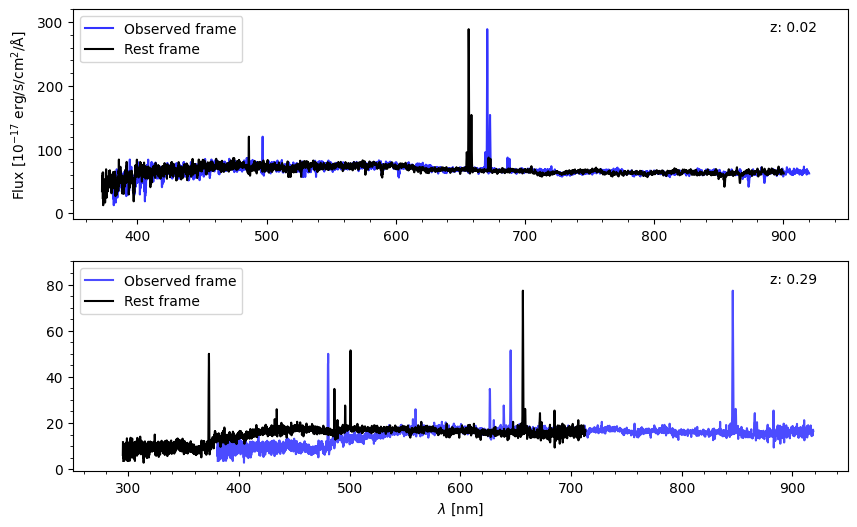

In [115]:
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=False,
)
# -------------------------------------------------
y_label = r'Flux [$10^{-17}$ erg/s/cm$^2$/Å]'
# -------------------------------------------------
# Spec 1
# Observed frame
axs[0].plot(
    raw_wave_1, dered_flux_1,
    color='blue', alpha=0.8,
    label='Observed frame'
)
axs[0].plot(
    rest_wave_1, dered_flux_1,
    color='black', alpha=1,
    label='Rest frame'
)

axs[0].legend(loc='upper left')
axs[0].text(
    0.9, 0.95,
    f'z: {z_1:.2f}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[0].set_xlim(350, 950)

axs[0].set_ylim(-10, 320) 
ticks = [0, 100, 200, 300]
axs[0].set_yticks(ticks)
axs[0].set_ylabel(y_label)

# -------------------------------------------------

# Spec 2
axs[1].plot(
    raw_wave_2, dered_flux_2,
    color='blue', alpha=0.7,
    label='Observed frame'
)
axs[1].plot(
    rest_wave_2, dered_flux_2,
    color='black', alpha=1,
    label='Rest frame'
)

axs[1].legend(loc='upper left') 
axs[1].text(
    0.9, 0.95,
    f'z: {z_2:.2f}', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[1].set_ylim(-1, 90) 
ticks = [0, 20, 40, 60, 80]
axs[1].set_yticks(ticks)

# axs[1].set_ylabel(y_label)
axs[1].set_xlim(250, 950)

# -------------------------------------------------
axs[-1].set_xlabel(r"$\lambda$ [nm]")
  
for ax in axs.flatten(): ax.minorticks_on()

# # adjust vertical space
# plt.subplots_adjust(
#     hspace=0.1,
#     # wspace=0.1
# )
fig.savefig(
    f"{ch_3_dir}/rest_frame.pdf",
    bbox_inches='tight'
)

# Interpolation to a common grid

## Data

3500.0 7500.0


In [ ]:
# Spec 1
spec_1_location = f'{fits_files_dir}/spec-1254-52972-0209.fits'
(
    raw_flux_1, sky_1,
    raw_wave_1, ivar_1, specobjid_1
) = get_data_from_fits_file(spec_1_location)


raw_flux_OI_interpolated_1 = OI_5577_interpolation(
    raw_wave_1.copy(), raw_flux_1.copy()
)

flux_noise_masking_1, variance_1 = remove_large_uncertainties(
    raw_flux_OI_interpolated_1, ivar_1
)

ebv_1 = drop_meta_data_df.loc[specobjid_1, 'ebv']

dered_flux_1 = dered_spectrum(flux_noise_masking_1, raw_wave_1, ebv=ebv_1)

z_1 = drop_meta_data_df.loc[specobjid_1, 'z']
rest_wave_1 = raw_wave_1 / (1 + z_1)

interp_flux_1 = np.interp(
    wave_grid, rest_wave_1,
    dered_flux_1,
    left=np.nan, right=np.nan
)

E(B-V): 0.4226
z_1: 0.0219
min rest wave 1: 3725.56 nm
max observed wave 1: 9200.26 nm
--------------------------------------------------


In [125]:
# -------------------------------------------------
# Spec 2
spec_2_location = f'{fits_files_dir}/spec-0553-51999-0224.fits'
(
    raw_flux_2, sky_2,
    raw_wave_2, ivar_2, specobjid_2
) = get_data_from_fits_file(spec_2_location)


raw_flux_OI_interpolated_2 = OI_5577_interpolation(
    raw_wave_2.copy(), raw_flux_2.copy()
)

flux_noise_masking_2, variance_2 = remove_large_uncertainties(
    raw_flux_OI_interpolated_2, ivar_2
)

ebv_2 = drop_meta_data_df.loc[specobjid_2, 'ebv']

dered_flux_2 = dered_spectrum(raw_flux_OI_interpolated_2, raw_wave_2, ebv=ebv_2)

z_2 = drop_meta_data_df.loc[specobjid_2, 'z']
rest_wave_2 = raw_wave_2 / (1 + z_2) 

interp_flux_2 = np.interp(
    wave_grid, rest_wave_2,
    dered_flux_2,
    left=np.nan, right=np.nan
)

## Figure

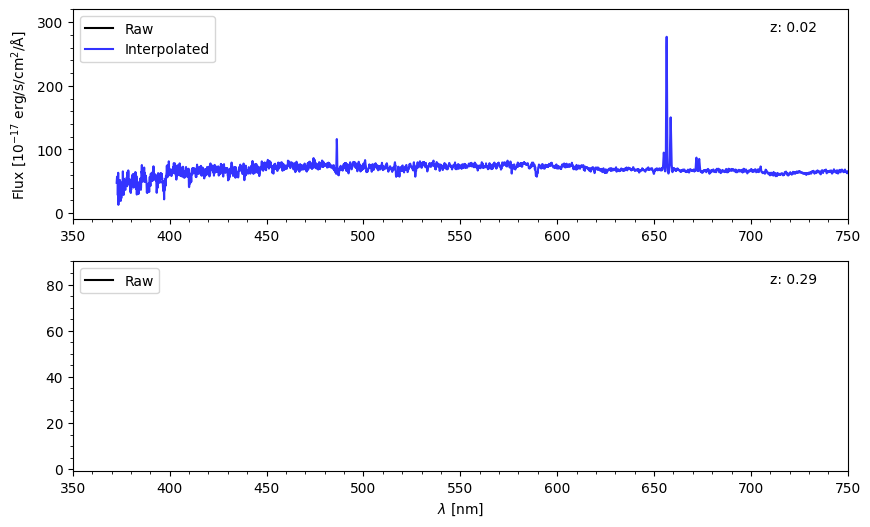

In [126]:
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=False,
)
# -------------------------------------------------
y_label = r'Flux [$10^{-17}$ erg/s/cm$^2$/Å]'
# convert waves to nm
wave_interp = wave_grid*0.1
rest_wave_1_nm = raw_wave_1*0.1 
# -------------------------------------------------
# Spec 1
# Observed frame

axs[0].plot(
    rest_wave_1, dered_flux_1,
    color='black', alpha=1,
    label='Raw'
)
axs[0].plot(
    wave_interp, interp_flux_1,
    color='blue', alpha=0.8,
    label='Interpolated'
)
axs[0].legend(loc='upper left')
axs[0].text(
    0.9, 0.95,
    f'z: {z_1:.2f}', 
    transform=axs[0].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[0].set_xlim(350, 750)

axs[0].set_ylim(-10, 320) 
ticks = [0, 100, 200, 300]
axs[0].set_yticks(ticks)
axs[0].set_ylabel(y_label)

# -------------------------------------------------

# Spec 2

axs[1].plot(
    rest_wave_2, dered_flux_2,
    color='black', alpha=1,
    label='Raw'
)
# axs[1].plot(
#     wave_interp, interp_flux_2,
#     color='blue', alpha=0.8,
#     label='Interpolated'
# )

axs[1].legend(loc='upper left') 
axs[1].text(
    0.9, 0.95,
    f'z: {z_2:.2f}', 
    transform=axs[1].transAxes, 
    # fontsize=14, 
    verticalalignment='top', 
    # fontweight='bold'
)
axs[1].set_ylim(-1, 90) 
ticks = [0, 20, 40, 60, 80]
axs[1].set_yticks(ticks)

# axs[1].set_ylabel(y_label)
axs[1].set_xlim(350, 750)

# -------------------------------------------------
axs[-1].set_xlabel(r"$\lambda$ [nm]")
  
for ax in axs.flatten(): ax.minorticks_on()

# # adjust vertical space
# plt.subplots_adjust(
#     hspace=0.1,
#     # wspace=0.1
# )
fig.savefig(
    f"{ch_3_dir}/common_grid_interpolation.pdf",
    bbox_inches='tight'
)